<a href="https://www.kaggle.com/code/omborse771924/ai-restaurant-calling-agent-eda?scriptVersionId=330279466" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shanza30/ai-caller-agent/ai_calling_agent_dataset_1000.csv


## Loading Dataset


In [2]:
df = pd.read_csv('/kaggle/input/datasets/shanza30/ai-caller-agent/ai_calling_agent_dataset_1000.csv')

In [3]:
df.head()

,text,intent,time,food_item,location
0,"Hi, Order food for me right now",order,9 PM,pasta,main road
1,"Hi, Hi quickly",greeting,6 PM,sandwich,near mall
2,"Hello, Table for 4 at 8 PM right now",reservation,8 PM,pasta,downtown
3,Hi please,greeting,7 PM,burger,main road
4,"Hey, What are your timings?",query,9 PM,pizza,downtown


In [4]:
df.tail()

,text,intent,time,food_item,location
1195,"Hello, My order is late right now",complaint,7 PM,pasta,near mall
1196,"Hi, I need a reservation right now",reservation,10 PM,sandwich,main road
1197,Hey right now,greeting,7 PM,pasta,downtown
1198,"Hello, Reserve a table tonight",reservation,6 PM,pizza,city center
1199,"Hi, Send me a burger quickly",order,6 PM,pizza,city center


In [5]:
df.describe()

,text,intent,time,food_item,location
count,1200,1200,1200,1200,1200
unique,452,6,5,5,4
top,"Excuse me, This is disappointing quickly",greeting,8 PM,sandwich,city center
freq,9,212,260,253,315


In [6]:
df.isnull()

,text,intent,time,food_item,location
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
1195,False,False,False,False,False
1196,False,False,False,False,False
1197,False,False,False,False,False
1198,False,False,False,False,False


In [7]:
df.isnull().sum()

text         0
intent       0
time         0
food_item    0
location     0
dtype: int64

In [8]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1195    False
1196    False
1197    False
1198    False
1199    False
Length: 1200, dtype: bool

In [9]:
df.duplicated().sum()

np.int64(14)

In [10]:
df.columns

Index(['text', 'intent', 'time', 'food_item', 'location'], dtype='object')

## EDA


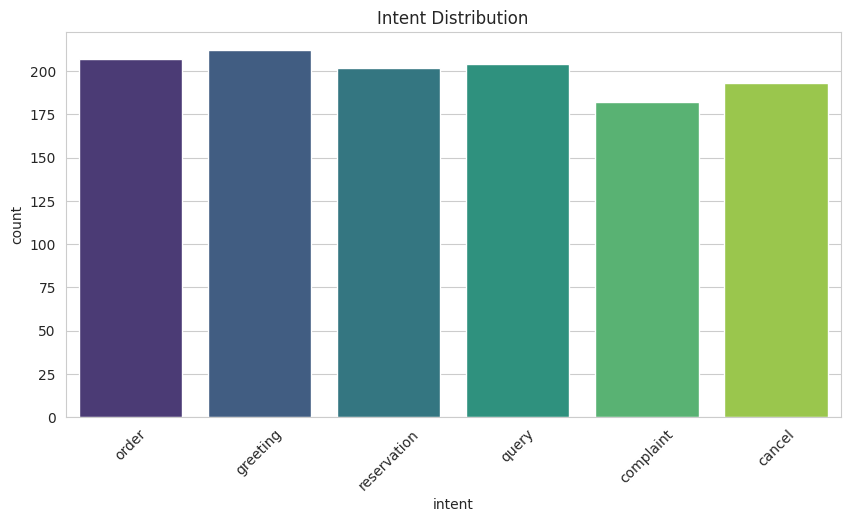

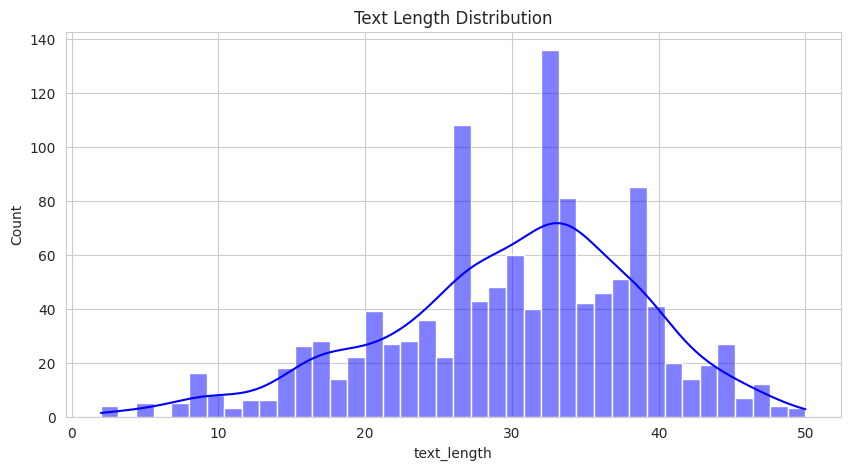

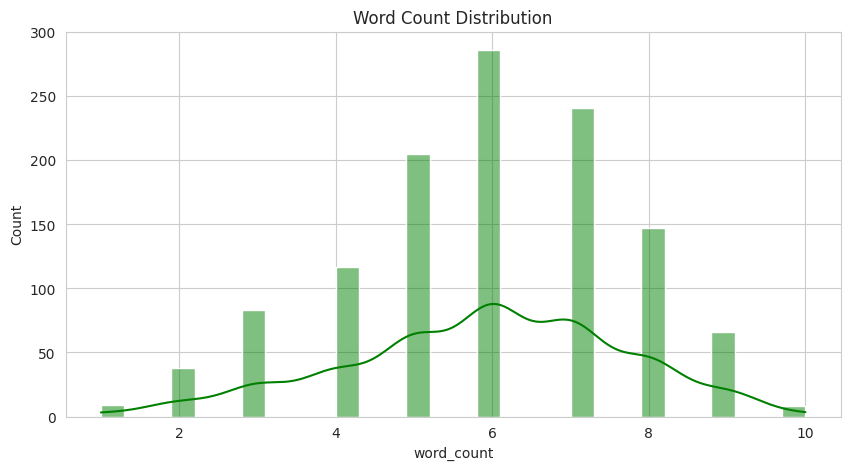

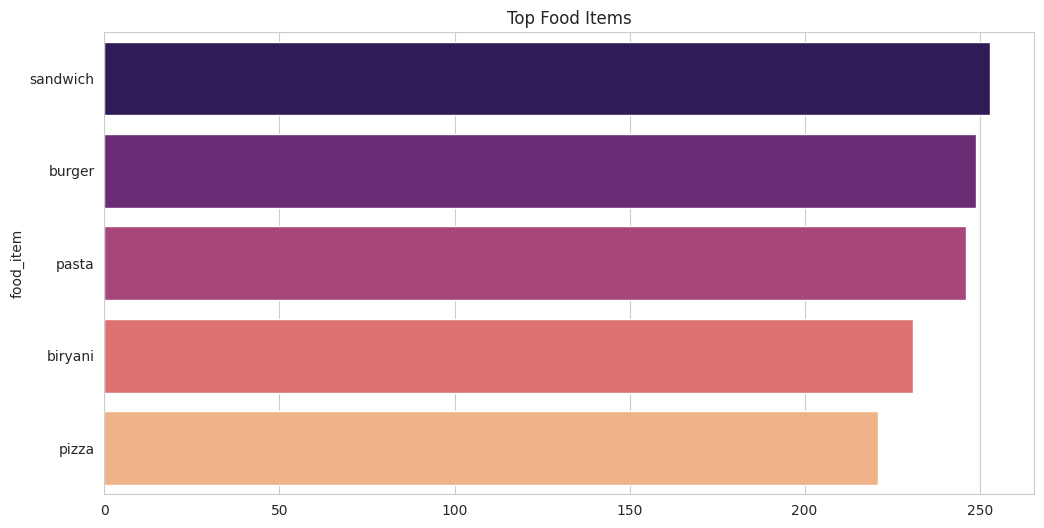

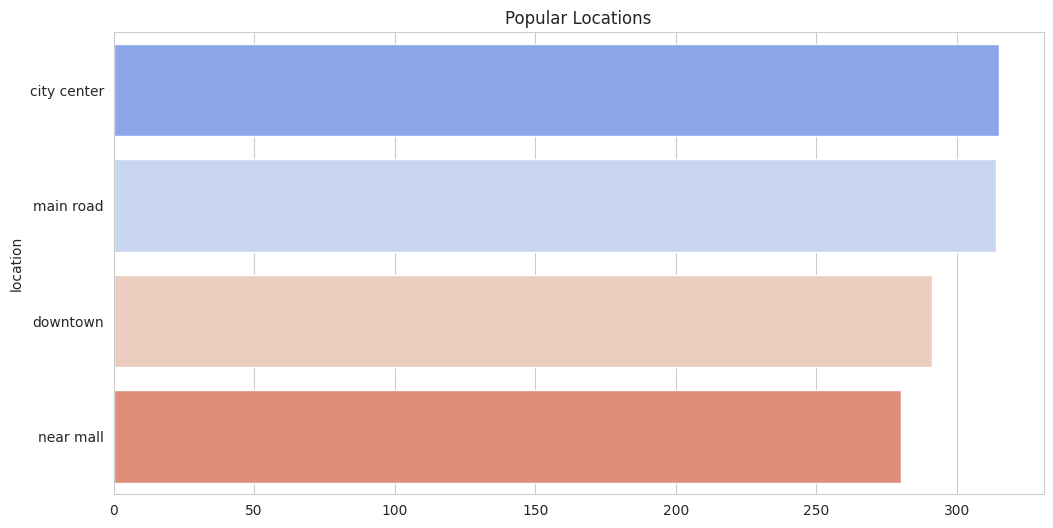

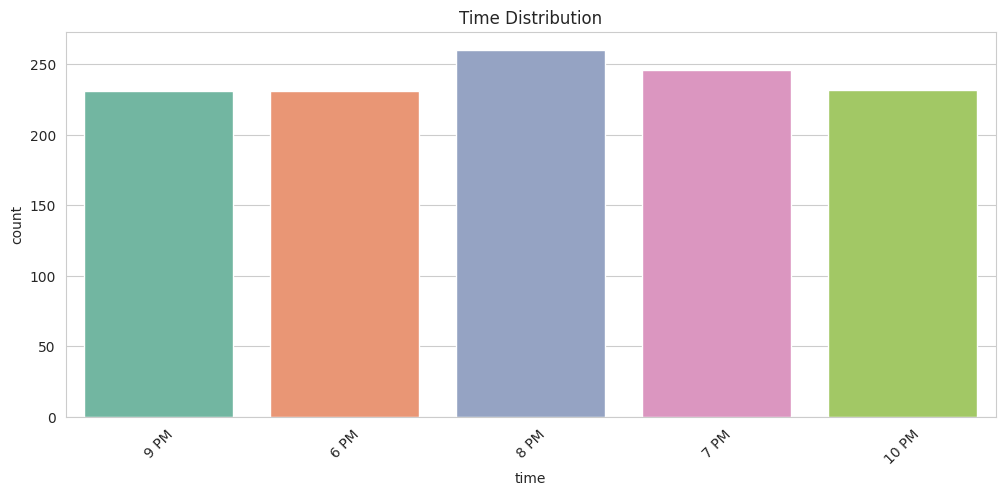

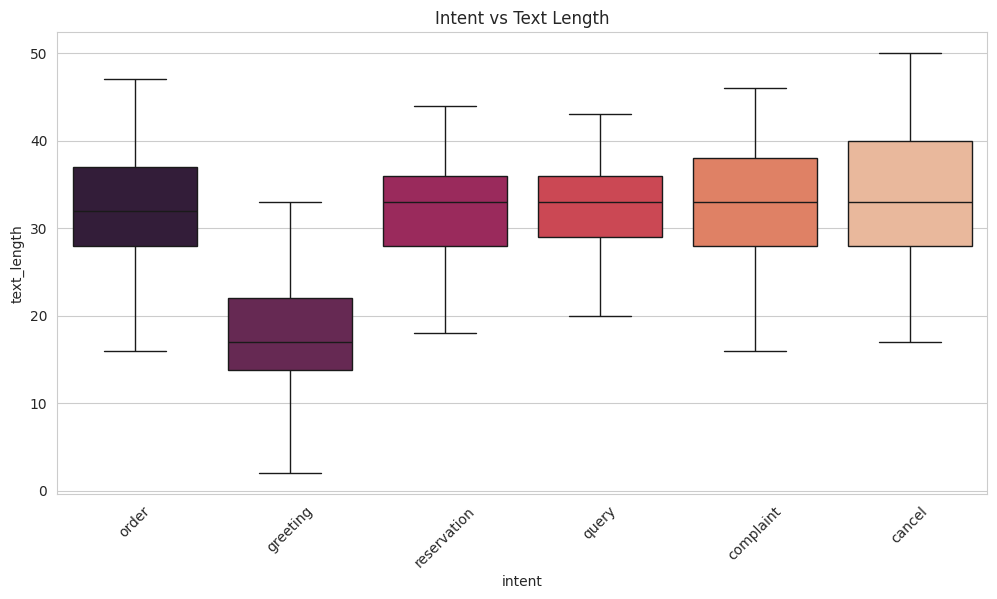

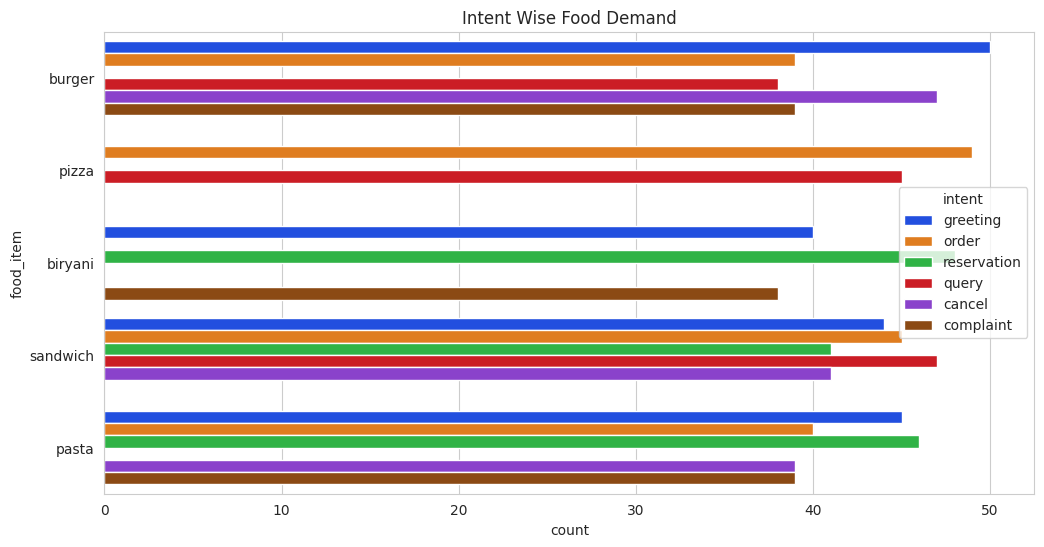

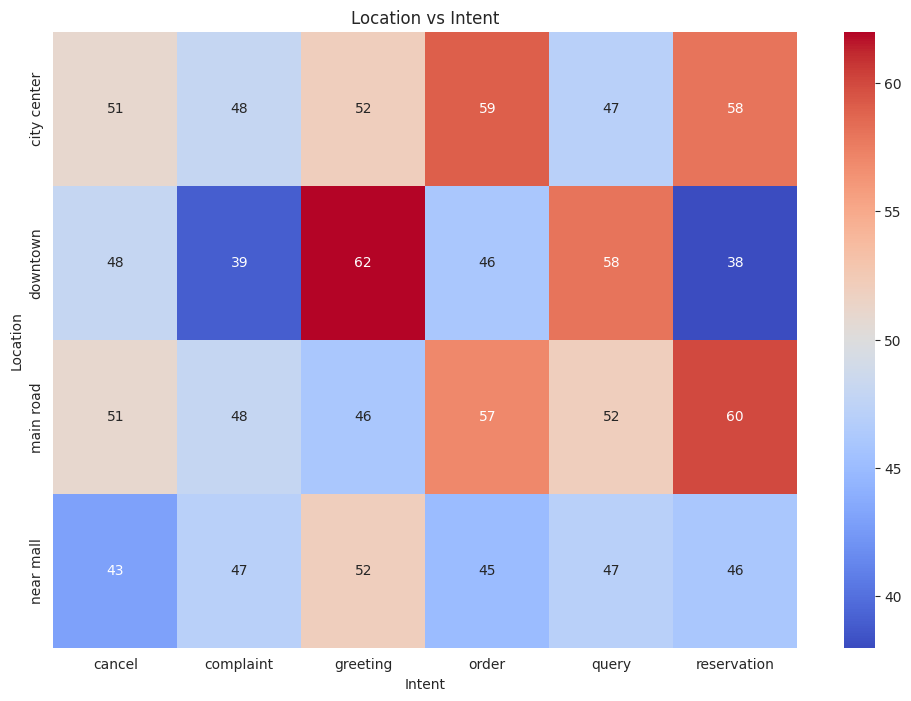

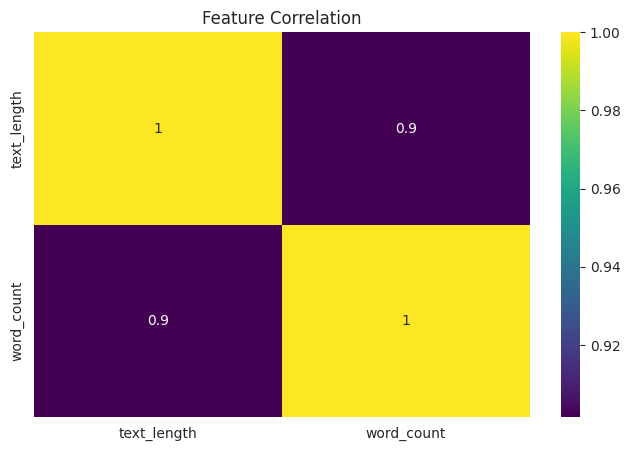

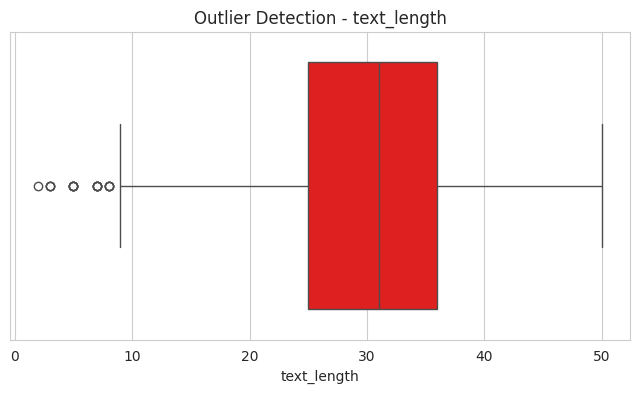

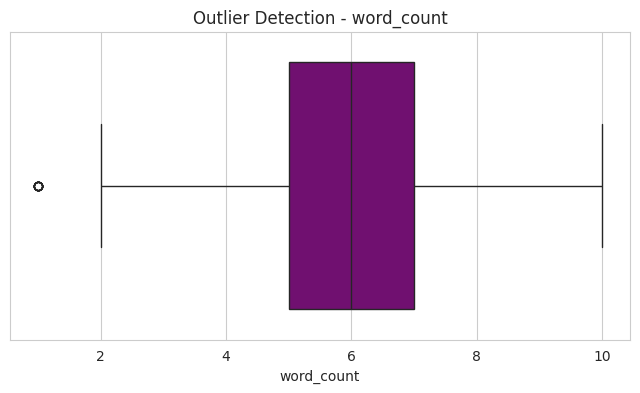

FOOD INTENT VISUALIZATION COMPLETED SUCCESSFULLY


In [11]:

sns.set_style("whitegrid")
# ============================================================
# FEATURE ENGINEERING
# ============================================================


df["text_length"] = (

    df["text"]

    .astype(str)

    .apply(len)

)



df["word_count"] = (

    df["text"]

    .astype(str)

    .apply(lambda x: len(x.split()))

)










# ============================================================
# 1. INTENT DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.countplot(

    data=df,

    x="intent",

    hue="intent",

    palette="viridis",

    legend=False

)


plt.title(
    "Intent Distribution"
)


plt.xticks(rotation=45)


plt.show()










# ============================================================
# 2. TEXT LENGTH DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["text_length"],

    bins=40,

    kde=True,

    color="blue"

)



plt.title(
    "Text Length Distribution"
)



plt.show()










# ============================================================
# 3. WORD COUNT DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["word_count"],

    bins=30,

    kde=True,

    color="green"

)



plt.title(
    "Word Count Distribution"
)


plt.show()











# ============================================================
# 4. FOOD ITEM POPULARITY
# ============================================================


food = (

    df["food_item"]

    .value_counts()

    .head(20)

)




plt.figure(figsize=(12,6))


sns.barplot(

    x=food.values,

    y=food.index,

    hue=food.index,

    palette="magma",

    legend=False

)



plt.title(
    "Top Food Items"
)


plt.show()











# ============================================================
# 5. LOCATION ANALYSIS
# ============================================================


location = (

    df["location"]

    .value_counts()

    .head(20)

)




plt.figure(figsize=(12,6))


sns.barplot(

    x=location.values,

    y=location.index,

    hue=location.index,

    palette="coolwarm",

    legend=False

)



plt.title(
    "Popular Locations"
)


plt.show()











# ============================================================
# 6. TIME ANALYSIS
# ============================================================


plt.figure(figsize=(12,5))


sns.countplot(

    data=df,

    x="time",

    hue="time",

    palette="Set2",

    legend=False

)


plt.title(
    "Time Distribution"
)


plt.xticks(rotation=45)


plt.show()











# ============================================================
# 7. INTENT VS TEXT LENGTH
# ============================================================


plt.figure(figsize=(12,6))


sns.boxplot(

    data=df,

    x="intent",

    y="text_length",

    hue="intent",

    palette="rocket",

    legend=False

)



plt.title(
    "Intent vs Text Length"

)



plt.xticks(rotation=45)



plt.show()










# ============================================================
# 8. INTENT WISE FOOD DEMAND
# ============================================================


intent_food = (

    df.groupby(

        ["intent","food_item"]

    )

    .size()

    .reset_index(name="count")

)





intent_food = (

    intent_food

    .sort_values(

        "count",

        ascending=False

    )

    .head(20)

)







plt.figure(figsize=(12,6))


sns.barplot(

    data=intent_food,

    x="count",

    y="food_item",

    hue="intent",

    palette="bright"

)



plt.title(
    "Intent Wise Food Demand"
)



plt.show()


# ============================================================
# 10. LOCATION VS INTENT  (FIXED ERROR HERE)
# ============================================================


loc_intent = pd.crosstab(

    df["location"],

    df["intent"]

).head(20)







plt.figure(figsize=(12,8))


sns.heatmap(

    loc_intent,

    annot=True,

    cmap="coolwarm"

)



plt.title(

    "Location vs Intent"

)



plt.xlabel(

    "Intent"

)



plt.ylabel(

    "Location"

)



plt.show()











# ============================================================
# 11. CORRELATION HEATMAP
# ============================================================


numeric = df.select_dtypes(

    include=np.number

)





plt.figure(figsize=(8,5))


sns.heatmap(

    numeric.corr(),

    annot=True,

    cmap="viridis"

)



plt.title(

    "Feature Correlation"

)



plt.show()










# ============================================================
# 12. OUTLIER DETECTION
# ============================================================


features=[

    "text_length",

    "word_count"

]


colors=[

    "red",

    "purple"

]





for f,c in zip(features,colors):


    plt.figure(figsize=(8,4))


    sns.boxplot(

        x=df[f],

        color=c

    )



    plt.title(

        f"Outlier Detection - {f}"

    )



    plt.show()










print(
    "FOOD INTENT VISUALIZATION COMPLETED SUCCESSFULLY"
)

## Features Engineering

Classes: ['cancel' 'complaint' 'greeting' 'order' 'query' 'reservation']

Logistic Regression
Accuracy: 1.0
              precision    recall  f1-score   support

      cancel       1.00      1.00      1.00        39
   complaint       1.00      1.00      1.00        36
    greeting       1.00      1.00      1.00        42
       order       1.00      1.00      1.00        42
       query       1.00      1.00      1.00        41
 reservation       1.00      1.00      1.00        40

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240


Decision Tree
Accuracy: 1.0
              precision    recall  f1-score   support

      cancel       1.00      1.00      1.00        39
   complaint       1.00      1.00      1.00        36
    greeting       1.00      1.00      1.00        42
       order       1.00      1.00      1.00        42
       query       1.00      1.00      1.00      

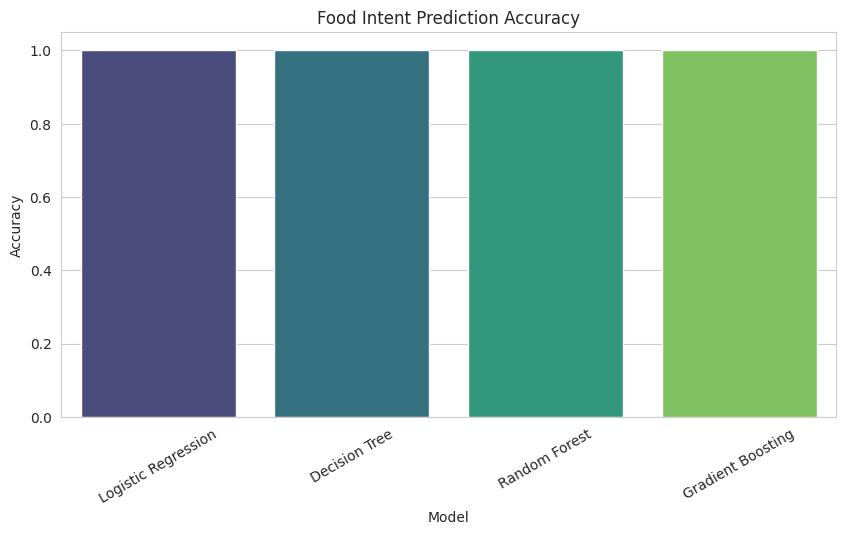

BEST MODEL: Logistic Regression


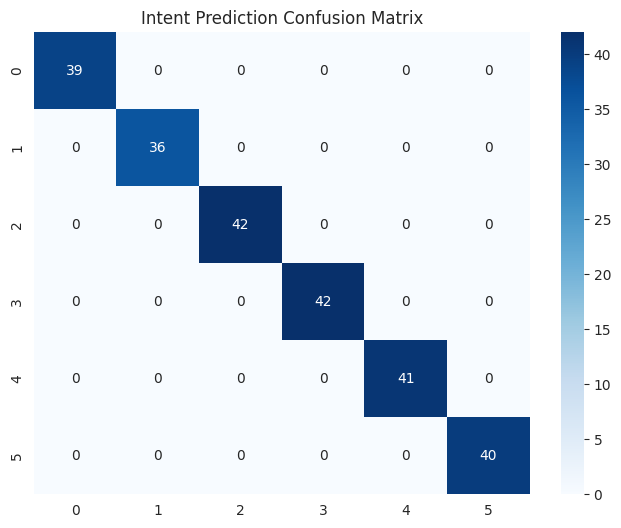

MULTICLASS ROC-AUC: 1.0

FINAL MODEL RESULTS
Logistic Regression : 1.0
Decision Tree : 1.0
Random Forest : 1.0
Gradient Boosting : 1.0
BEST MODEL: Logistic Regression
BEST ACCURACY: 1.0


In [12]:
from sklearn.model_selection import train_test_split


from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder
)


from sklearn.feature_extraction.text import TfidfVectorizer


from sklearn.compose import ColumnTransformer


from sklearn.pipeline import Pipeline



from sklearn.linear_model import LogisticRegression


from sklearn.tree import DecisionTreeClassifier


from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)



from sklearn.metrics import (

    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score

)
# ============================================================
# HANDLE NULL VALUES
# ============================================================


df["text"]=df["text"].fillna("")


for col in [

    "time",

    "food_item",

    "location"

]:

    df[col]=df[col].fillna(

        df[col].mode()[0]

    )









# ============================================================
# TARGET
# ============================================================


target="intent"



X=df.drop(

    target,

    axis=1

)



y=df[target]









# ============================================================
# LABEL ENCODE TARGET ONLY
# ============================================================


le=LabelEncoder()



y=le.fit_transform(

    y

)



print(

"Classes:",

le.classes_

)










# ============================================================
# TRAIN TEST SPLIT FIRST
# ============================================================



X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)










# ============================================================
# PREPROCESSING
# ============================================================



preprocessor=ColumnTransformer(

transformers=[



(

"text",

TfidfVectorizer(

max_features=5000,

stop_words="english"

),

"text"

),





(

"cat",

OneHotEncoder(

handle_unknown="ignore"

),

[

"time",

"food_item",

"location"

]

)



]

)









# ============================================================
# ML ALGORITHMS
# ============================================================



models={



"Logistic Regression":

LogisticRegression(

max_iter=1000

),






"Decision Tree":

DecisionTreeClassifier(

random_state=42

),






"Random Forest":

RandomForestClassifier(

n_estimators=200,

random_state=42,

n_jobs=-1

),






"Gradient Boosting":

GradientBoostingClassifier(

random_state=42

)



}










results={}

trained={}










# ============================================================
# TRAIN MODELS
# ============================================================


for name,model in models.items():



    print("\n====================")
    print(name)
    print("====================")




    pipe=Pipeline(

    steps=[



    (

    "preprocess",

    preprocessor

    ),




    (

    "model",

    model

    )



    ]

    )









    pipe.fit(

        X_train,

        y_train

    )








    pred=pipe.predict(

        X_test

    )








    acc=accuracy_score(

        y_test,

        pred

    )






    results[name]=acc

    trained[name]=pipe








    print(

    "Accuracy:",

    round(acc,4)

    )




    print(

    classification_report(

        y_test,

        pred,

        target_names=le.classes_

    )

    )









# ============================================================
# ACCURACY GRAPH
# ============================================================



accuracy_df=pd.DataFrame({


"Model":list(results.keys()),


"Accuracy":list(results.values())


})





plt.figure(figsize=(10,5))


sns.barplot(

data=accuracy_df,

x="Model",

y="Accuracy",

hue="Model",

palette="viridis",

legend=False

)



plt.title(

"Food Intent Prediction Accuracy"

)


plt.xticks(rotation=30)


plt.show()










# ============================================================
# BEST MODEL
# ============================================================


best_name=max(

results,

key=results.get

)



best_model=trained[

best_name

]





print(

"BEST MODEL:",

best_name

)










# ============================================================
# CONFUSION MATRIX
# ============================================================



best_pred=best_model.predict(

X_test

)





plt.figure(figsize=(8,6))


sns.heatmap(

confusion_matrix(

y_test,

best_pred

),

annot=True,

fmt="d",

cmap="Blues"

)



plt.title(

"Intent Prediction Confusion Matrix"

)


plt.show()










# ============================================================
# ROC CURVE
# Binary + Multiclass
# ============================================================


prob=best_model.predict_proba(

X_test

)






if len(le.classes_)==2:



    fpr,tpr,_=roc_curve(

        y_test,

        prob[:,1]

    )





    auc=roc_auc_score(

        y_test,

        prob[:,1]

    )






    plt.figure(figsize=(8,6))



    plt.plot(

    fpr,

    tpr,

    label=f"AUC={auc:.3f}"

    )



    plt.plot(

    [0,1],

    [0,1],

    "k--"

    )




    plt.xlabel(

    "False Positive Rate"

    )



    plt.ylabel(

    "True Positive Rate"

    )




    plt.title(

    "ROC Curve"

    )


    plt.legend()


    plt.show()




else:



    auc=roc_auc_score(

        y_test,

        prob,

        multi_class="ovr"

    )



    print(

    "MULTICLASS ROC-AUC:",

    round(auc,4)

    )










# ============================================================
# FINAL RESULTS
# ============================================================



print("\nFINAL MODEL RESULTS")


print("========================")



for model,score in results.items():



    print(

    model,

    ":",

    round(score,4)

    )





print("========================")


print(

"BEST MODEL:",

best_name

)



print(

"BEST ACCURACY:",

round(max(results.values()),4)

)

## Thanks.........please upvote